# Error Analysis — GSM-MC

**Benchmark:** GSM-MC
**Description:** Math word problems in MC form; 1-of-4
**Random baseline:** 25%
**Our generator(s) targeting this:** Gen D (Quantitative)

This notebook drills into why the model isn't getting a higher score. It:
1. Splits every question into `answerable` / `unanswerable` / `ambiguous` using a hybrid keyword + LLM-judge classifier (cached).
2. Reports accuracy stratified by answerability — so we see real model capability, not just raw score.
3. Examines confidence on wrong answers (high-confidence wrong = learned wrong pattern).
4. Surfaces the highest-confidence wrong answers on the *answerable* subset — these are the diagnostic gold.
5. Compares Mid vs SFT phases to see where the gap closed or opened.
6. Delivers a one-line verdict: content gap, skill gap, or both.

In [1]:
import sys
from pathlib import Path

# Ensure project root is importable
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "post_training").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.post_training.analysis import (
    load_details, load_classifications, classify_batch,
    accuracy_triple, confidence_breakdown, high_confidence_wrong,
    plot_confidence_histogram, extract_stem_and_choices,
)
from src.post_training.analysis.answerability import _hash_question

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

BENCHMARK = "GSM-MC"
RANDOM_BASELINE = 0.25

BASE = Path(r'D:/hist_LLM/periods/1900_1949/error_analysis_new')
CACHE = BASE / '.answerability_cache' / f'{BENCHMARK}.jsonl'

STAGES = ['mid_final', 'sft_final', 'sft_final_debiased']
dfs = {}
for stage in STAGES:
    p = BASE / stage / f'{BENCHMARK}_details.jsonl'
    dfs[stage] = load_details(p)
    print(f'{stage}: {len(dfs[stage])} rows')

mid_final: 335 rows
sft_final: 335 rows
sft_final_debiased: 335 rows


## 1. Answerability Classifications

Load the cached classifications. If the cache is missing, build it now.
(Classifier is hybrid: keyword filter first, then LLM judge for the ambiguous middle.)

In [2]:
classes = load_classifications(CACHE)
print(f'Cached classifications: {len(classes)}')

if len(classes) < len(dfs['mid_final']):
    print('Cache incomplete — building now...')
    questions = []
    for i, row in dfs['mid_final'].iterrows():
        questions.append({'index': int(row['index']), 'question': row['question']})
    classify_batch(questions, CACHE, start_year=1900, end_year=1949)
    classes = load_classifications(CACHE)
    print(f'Now cached: {len(classes)}')

from collections import Counter
label_counts = Counter(r['label'] for r in classes.values())
print(f'\nLabel distribution: {dict(label_counts)}')

Cached classifications: 335

Label distribution: {'unanswerable': 38, 'answerable': 297}


## 2. Accuracy Stratified by Answerability

The headline question: **on the subset the model COULD answer with period knowledge, how well does it do?**

In [3]:
rows = []
for stage in STAGES:
    if dfs[stage].empty: continue
    trip = accuracy_triple(dfs[stage], classes)
    for bucket, stats in trip.items():
        if stats['acc'] is None: continue
        rows.append({
            'stage': stage, 'bucket': bucket,
            'n': stats['n'], 'correct': stats['correct'],
            'acc_%': round(100 * stats['acc'], 1),
            'vs_random_%': round(100 * (stats['acc'] - RANDOM_BASELINE), 1),
        })
summary = pd.DataFrame(rows)
print(f'Random baseline: {100*RANDOM_BASELINE:.0f}%')
summary

Random baseline: 25%


,stage,bucket,n,correct,acc_%,vs_random_%
0,mid_final,overall,335,78,23.3,-1.7
1,mid_final,answerable,297,66,22.2,-2.8
2,mid_final,unanswerable,38,12,31.6,6.6
3,sft_final,overall,335,77,23.0,-2.0
4,sft_final,answerable,297,66,22.2,-2.8
5,sft_final,unanswerable,38,11,28.9,3.9
6,sft_final_debiased,overall,335,82,24.5,-0.5
7,sft_final_debiased,answerable,297,72,24.2,-0.8
8,sft_final_debiased,unanswerable,38,10,26.3,1.3


## 3. Answerability Sanity Check

A sample of how the classifier labeled individual questions.

In [4]:
# Show 4 examples from each label
df_with_labels = dfs['mid_final'].copy()
df_with_labels['qhash'] = df_with_labels['question'].map(_hash_question)
df_with_labels['label'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
df_with_labels['reason'] = df_with_labels['qhash'].map(lambda h: classes.get(h,{}).get('reason',''))
for label in ['answerable','unanswerable','ambiguous']:
    subset = df_with_labels[df_with_labels['label'] == label]
    if len(subset) == 0: continue
    print(f'=== {label.upper()} ({len(subset)} total) — sampling 3 ===')
    for _, row in subset.sample(min(3, len(subset)), random_state=42).iterrows():
        parsed = extract_stem_and_choices(row['question'])
        print(f'  Q: {parsed["stem"][:200]}')
        if row['reason']: print(f'     reason: {row["reason"][:200]}')
    print()

=== ANSWERABLE (297 total) — sampling 3 ===
  Q: Alice has 6 more books than Steven. Clara has two times as many books as Steven. If Clara has 20 books, how many more books does Clara have than Alice?
     reason: The question involves basic arithmetic and relationships that were well understood during 1900-1949.
  Q: The combined age of Peter, Paul and Jean is 100 years old. Find the age of Peter knowing that Paul is 10 years older than John and that Peter’s age is equal to the sum of Paul and John's age.
     reason: The question involves basic arithmetic and relationships that were well understood during 1900-1949.
  Q: There are 6 trees in Chris's yard.  Ferdinand has half the number of trees that Chris has.  Harry has 5 more than twice the number of trees that Ferdinand has.  How many more trees are in Harry's yard
     reason: The question involves basic arithmetic and concepts about trees that were well understood during 1900-1949.

=== UNANSWERABLE (38 total) — sampling 3 ===
 

## 4. Confidence Distribution

Right vs wrong, split by answerability. High-confidence wrong on the *answerable* subset = model learned a wrong pattern.

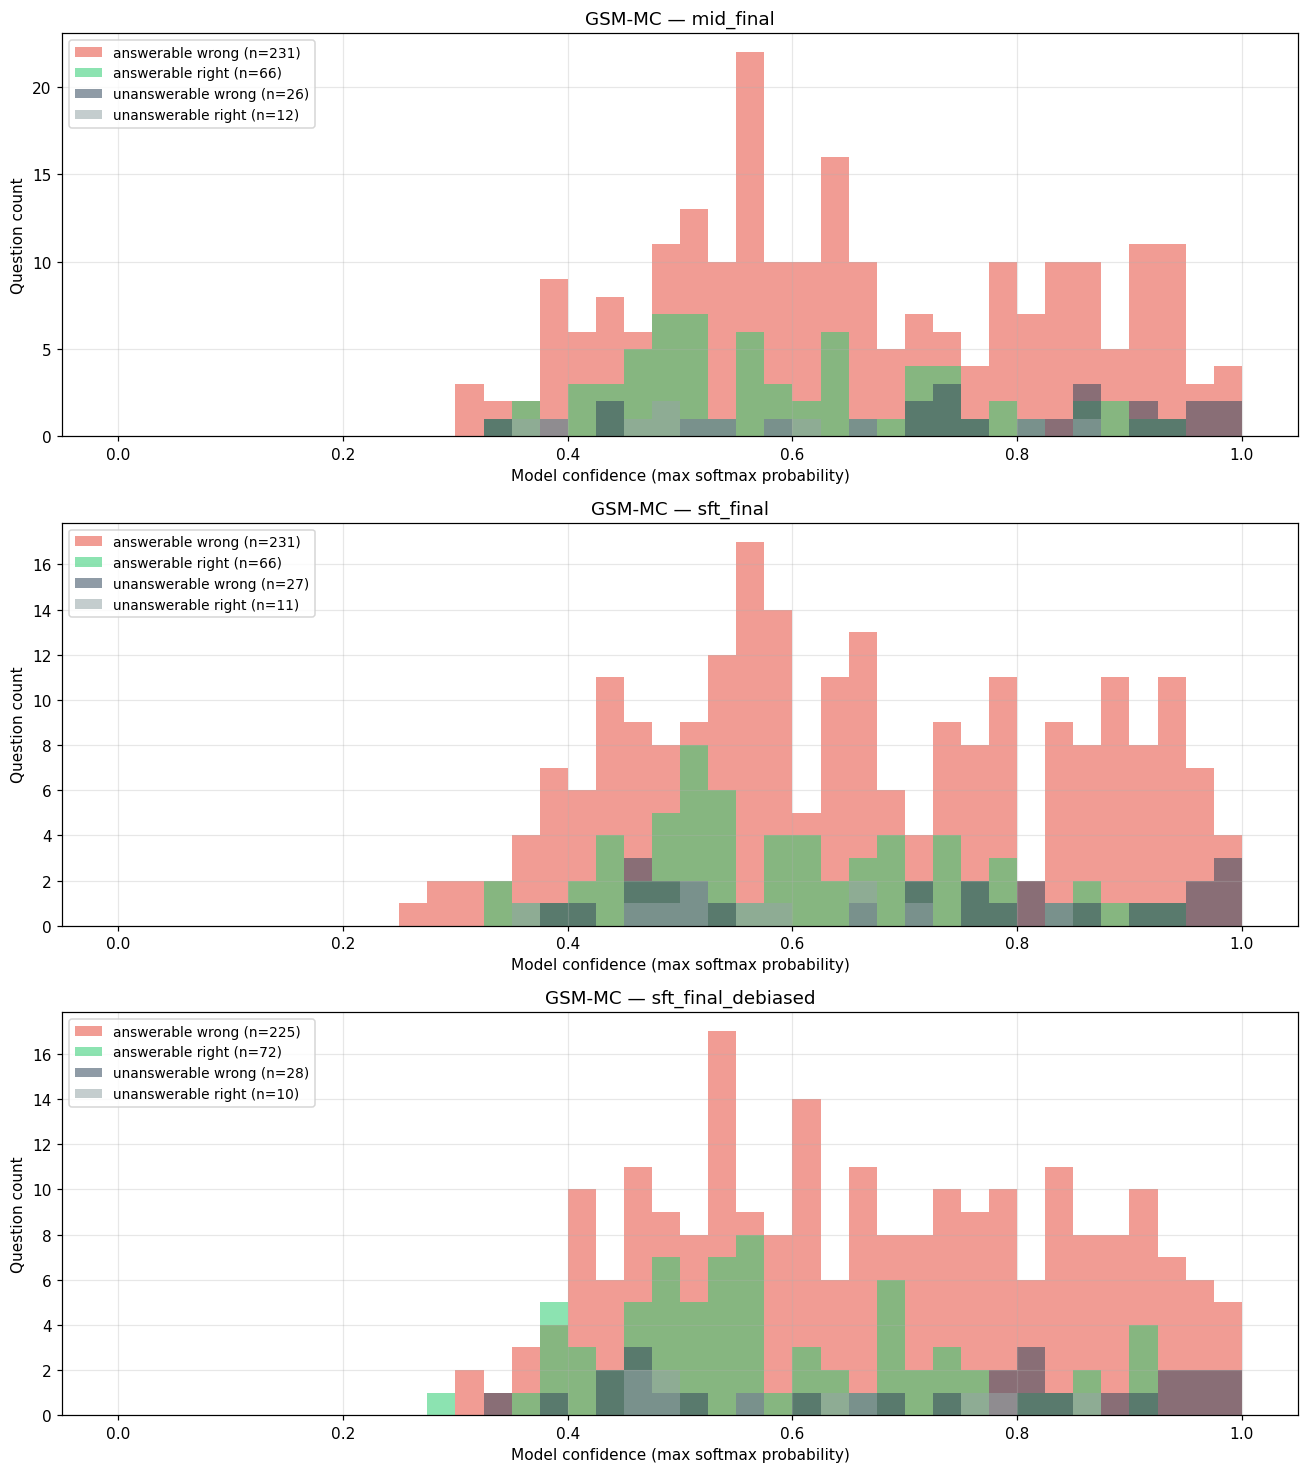

In [5]:
fig, axes = plt.subplots(len([s for s in STAGES if not dfs[s].empty]), 1, figsize=(12, 4.5*len([s for s in STAGES if not dfs[s].empty])))
axes = [axes] if not hasattr(axes, '__iter__') else axes
ax_iter = iter(axes)
for stage in STAGES:
    if dfs[stage].empty: continue
    ax = next(ax_iter)
    plot_confidence_histogram(dfs[stage], classes, title=f'{BENCHMARK} — {stage}', ax=ax)
plt.tight_layout()
plt.show()

## 5. High-Confidence Wrong Answers (answerable subset, Mid phase)

The diagnostic gold. These are questions the model should be able to answer using 1900-1949 knowledge, but got confidently wrong. Review these to identify patterns.

In [6]:
wrong = high_confidence_wrong(dfs['mid_final'], classes, label_filter='answerable', n=20, min_conf=0.5)
print(f'{len(wrong)} high-confidence wrong answers on the answerable subset\n')

for i, (_, row) in enumerate(wrong.iterrows(), 1):
    parsed = extract_stem_and_choices(row['question'])
    print(f'[{i:02d}] conf={row["confidence"]:.0%} pred={row["predicted"]} expected={row["expected"]}')
    print(f'     Q: {parsed["stem"][:280]}')
    for L in sorted(parsed['choices'].keys()):
        mark = ' ← PREDICTED' if L == row['predicted'] else (' ← CORRECT' if L == row['expected'] else '')
        print(f'       {L}: {parsed["choices"][L][:160]}{mark}')
    print()

20 high-confidence wrong answers on the answerable subset

[01] conf=100% pred=B expected=C
     Q: A hospital sees 500 people a day.  Each patient is seen for an average of 24 minutes.  The doctors charge $150 an hour to the hospital and the hospital charges the patients $200 an hour.  How much profit does the hospital make from these visits?
       A: 24000
       B: 96850 ← PREDICTED
       C: 10000 ← CORRECT
       D: 4200000

[02] conf=100% pred=B expected=A
     Q: John rents his car out 10 times a month for 3 hours each time.  He gets paid $25 an hour.  If his car payment is $500, how much profit does he make on his car?
       A: 250 ← CORRECT
       B: -250 ← PREDICTED
       C: 150
       D: 3750

[03] conf=99% pred=A expected=B
     Q: Mack wants to count things and decided to count how many birds there are in the sky over the next week. On days one and two, Mack saw a total of 50 birds. On day three he saw none. On days four and five, he saw 120 birds. On day six he saw 20 

## 6. Mid vs SFT on Answerable Subset

Did SFT help on the answerable slice, or did it just overfit to internal distribution?

In [7]:
if not dfs['sft_final'].empty:
    mid_trip = accuracy_triple(dfs['mid_final'], classes)
    sft_trip = accuracy_triple(dfs['sft_final'], classes)
    deb_trip = accuracy_triple(dfs['sft_final_debiased'], classes) if not dfs['sft_final_debiased'].empty else None
    rows = []
    for bucket in ['overall','answerable','unanswerable']:
        m = mid_trip.get(bucket,{}).get('acc')
        s = sft_trip.get(bucket,{}).get('acc')
        d = (deb_trip.get(bucket,{}).get('acc') if deb_trip else None)
        if m is None or s is None: continue
        rows.append({
            'bucket': bucket, 'n': mid_trip[bucket]['n'],
            'Mid_%': round(100*m,1), 'SFT_%': round(100*s,1),
            'Debiased_%': round(100*d,1) if d is not None else None,
            'SFT-Mid_delta': round(100*(s-m),1),
        })
    pd.DataFrame(rows)

## 7. Error-Type Clustering

What kinds of questions (within the answerable subset) does the model miss most?

In [8]:
# GSM-MC: cluster by operation count (proxy for step count)
import re
wrong_df = dfs['mid_final'][dfs['mid_final']['correct'] == False].copy()
wrong_df['qhash'] = wrong_df['question'].map(_hash_question)
wrong_df['label'] = wrong_df['qhash'].map(lambda h: classes.get(h,{}).get('label','ambiguous'))
ans_wrong = wrong_df[wrong_df['label']=='answerable']

# Count numbers in the question as a step-count proxy
def num_count(q):
    return len(re.findall(r'\b\d+(?:\.\d+)?\b', q))

ans_wrong['num_count'] = ans_wrong['question'].apply(num_count)
print('Step-count distribution on answerable wrong answers (number of numeric values in question):')
print(ans_wrong['num_count'].value_counts().sort_index())
print()

# Operation detection
OPS = {
    'addition': r'\b(total|sum|altogether|combined|plus|add)\b',
    'subtraction': r'\b(remaining|left|difference|fewer|less|minus|subtract)\b',
    'multiplication': r'\b(each|per|every|twice|double|triple|times)\b',
    'division': r'\b(divide|share|split|each|per|average|half|quarter|third)\b',
    'percent/fraction': r'\b(percent|%|half|quarter|third|fraction|tenth)\b',
}

for op, pat in OPS.items():
    hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]
    print(f'{op}: {len(hits)} answerable wrong (of {len(ans_wrong)})')

Step-count distribution on answerable wrong answers (number of numeric values in question):
num_count
4      4
5     16
6     53
7     63
8     47
9     26
10    13
11     5
12     3
13     1
Name: count, dtype: int64

addition: 59 answerable wrong (of 231)
subtraction: 40 answerable wrong (of 231)
multiplication: 141 answerable wrong (of 231)
division: 130 answerable wrong (of 231)
percent/fraction: 43 answerable wrong (of 231)


C:\Users\danielyoon\AppData\Local\Temp\ipykernel_31000\1716101428.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ans_wrong['num_count'] = ans_wrong['question'].apply(num_count)
C:\Users\danielyoon\AppData\Local\Temp\ipykernel_31000\1716101428.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = ans_wrong[ans_wrong['question'].str.contains(pat, case=False, regex=True, na=False)]


## 8. Verdict

Interpretation based on the answerable-subset accuracy:

- **answerable_acc > random + 15pp**: Real skill transfer. Model has the capability.
- **answerable_acc within ±5pp of random**: Skill gap. The model can't reason about even period-compatible content.
- **answerable_acc >> overall_acc**: Content gap dominates. Targeted synthetic data on modern vocabulary could help.
- **high-conf wrong clusters around one error type**: Targeted fix possible — rewrite the corresponding generator.

In [9]:
# Verdict computation
trip = accuracy_triple(dfs['mid_final'], classes)
overall = trip.get('overall', {}).get('acc', 0) or 0
answerable = trip.get('answerable', {}).get('acc', 0) or 0
unanswerable = trip.get('unanswerable', {}).get('acc', 0) or 0

verdict = []
if answerable > RANDOM_BASELINE + 0.15:
    verdict.append(f'✅ Real skill transfer: answerable={100*answerable:.1f}% vs random={100*RANDOM_BASELINE:.0f}%')
elif abs(answerable - RANDOM_BASELINE) < 0.05:
    verdict.append(f'⚠️ Skill gap: answerable subset at {100*answerable:.1f}% (near random).')
else:
    verdict.append(f'➖ Modest transfer: answerable={100*answerable:.1f}%, +{100*(answerable-RANDOM_BASELINE):.1f}pp vs random.')

if answerable - overall > 0.05:
    verdict.append(f'📈 Content gap contributes: answerable ({100*answerable:.1f}%) beats overall ({100*overall:.1f}%) by {100*(answerable-overall):.1f}pp.')

if unanswerable > RANDOM_BASELINE + 0.05:
    verdict.append(f'⚠️ Unanswerable subset at {100*unanswerable:.1f}% — model may be leaking modern knowledge.')

print('\n'.join(verdict))

⚠️ Skill gap: answerable subset at 22.2% (near random).
⚠️ Unanswerable subset at 31.6% — model may be leaking modern knowledge.
